## Task 1: Design and implement supervised classification models using Logistic Regression, Linear Discriminant Analysis (LDA), and k-Nearest Neighbors (k-NN)
*Suggested Dataset: Iris Dataset*

In [11]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [12]:
iris_raw = load_iris()
X_iris = iris_raw.data
y_iris = iris_raw.target

In [13]:
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris_scaled, y_iris, test_size=0.20, stratify=y_iris, random_state=42
)

In [15]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (120, 4)
Test set shape: (30, 4)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [17]:
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)
lr_model.fit(X_train, y_train)


LogisticRegression(multi_class='multinomial', random_state=42)

In [18]:
lr_preds = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

In [19]:
print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Test Accuracy: 93.33%


In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [21]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [22]:
lda_preds = lda_model.predict(X_test)
lda_accuracy = accuracy_score(y_test, lda_preds)

In [23]:
print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")

LDA Test Accuracy: 100.00%


In [24]:
# Import k-NN classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
knn = KNeighborsClassifier()

In [26]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [27]:
y_pred_knn = knn.predict(X_test)

In [28]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("k-NN Classification Accuracy:",knn_accuracy)

k-NN Classification Accuracy: 0.9333333333333333


In [29]:
# Assemble performance metrics
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100
    ]
})

print("--- Performance Comparison on Iris Dataset ---")
print(comparison_df.to_string(index=False))

--- Performance Comparison on Iris Dataset ---
             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          93.333333
Linear Discriminant Analysis (LDA)         100.000000
        k-Nearest Neighbors (k-NN)          93.333333


## Task 2: Develop classification models using Naïve Bayes and Support Vector Machines (SVM) for complex classification tasks
*Suggested Dataset: Sonar Dataset*

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']

# Scale features
scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

# Split into train/test sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [31]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Initialize and train Gaussian Naïve Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_s, y_train_s)

# Predict and evaluate accuracy
nb_preds = nb_model.predict(X_test_s)
nb_accuracy = accuracy_score(y_test_s, nb_preds)

print(f"Gaussian Naïve Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")

Gaussian Naïve Bayes Test Accuracy: 76.19%


In [32]:
from sklearn.svm import SVC

# Initialize and train Support Vector Classifier with Linear Kernel
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_s, y_train_s)

# Predict and evaluate accuracy
linear_preds = svm_linear.predict(X_test_s)
linear_accuracy = accuracy_score(y_test_s, linear_preds)

print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy * 100:.2f}%")

Linear Kernel SVM Test Accuracy: 79.37%


In [33]:
# Assemble performance metrics
sonar_comparison = pd.DataFrame({
    'Classifier': ['Gaussian Naïve Bayes (Probabilistic)', 'Linear Kernel SVM (Maximum-Margin)'],
    'Test Accuracy (%)': [nb_accuracy * 100, linear_accuracy * 100]
})

print("--- Performance Comparison on High-Dimensional Sonar Dataset ---")
print(sonar_comparison.to_string(index=False))

--- Performance Comparison on High-Dimensional Sonar Dataset ---
                          Classifier  Test Accuracy (%)
Gaussian Naïve Bayes (Probabilistic)          76.190476
  Linear Kernel SVM (Maximum-Margin)          79.365079


## Task 3: Analyze model performance using confusion matrix, precision, recall, F1-score, ROC analysis, and cross-validation techniques.

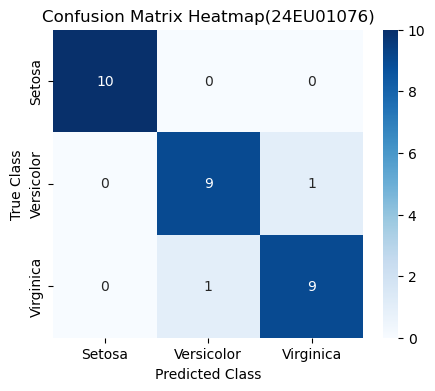

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix on Logistic Regression predictions
cm = confusion_matrix(y_test, lr_preds)

# Plot confusion matrix using a Seaborn heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.title("Confusion Matrix Heatmap(24EU01076)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [35]:
from sklearn.metrics import classification_report

# Generate classification report for Logistic Regression
report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

print("--- Logistic Regression Classification Report ---")
print(report_output)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



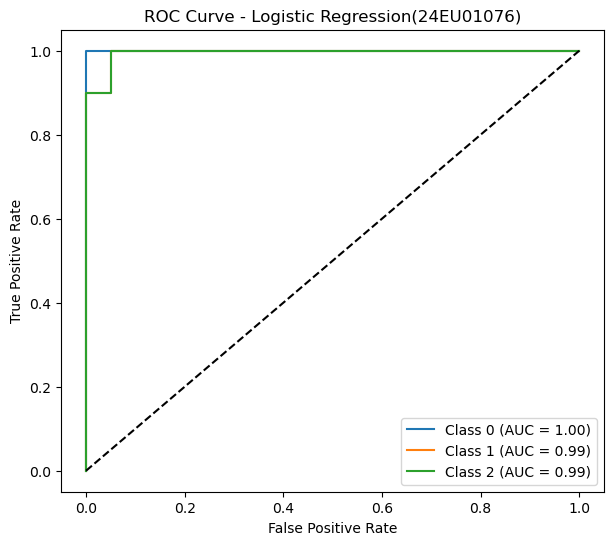

In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert test labels to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get predicted probabilities
y_score = lr_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression(24EU01076)")
plt.legend(loc="lower right")
plt.show()

In [37]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=200)

# Perform 5-fold Cross Validation
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

# Display results
print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

5-Fold Cross-Validation Accuracy:
Fold 1: 0.9667
Fold 2: 1.0000
Fold 3: 0.9333
Fold 4: 0.9000
Fold 5: 1.0000

Mean Accuracy: 96.00%
Standard Deviation: 3.89%
